### Multiscale Entropy


In [ ]:
import os
import numpy as np
import nolds

def coarse_grain(time_series, scale):
    """Create coarse-grained time series."""
    n = len(time_series)
    if n % scale == 0:
        m = n // scale
    else:
        m = n // scale + 1  # ensure that the length of the coarse-grained time series is sufficient
    coarse_ts = np.zeros(m)
    for i in range(m):
        start = i * scale
        end = min(start + scale, n)
        coarse_ts[i] = np.mean(time_series[start:end])
    return coarse_ts

def multiscale_entropy(time_series, max_scale, emb_dim=2, tolerance='default'):
    """Compute multiscale entropy of the given time series."""
    mse = np.zeros(max_scale)
    for scale in range(1, max_scale + 1):
        coarse_ts = coarse_grain(time_series, scale)
        if tolerance == 'default':
            # Set tolerance to 0.1 times the standard deviation of the original time series.
            tolerance = 0.1 * np.std(time_series)
        mse[scale-1] = nolds.sampen(coarse_ts, emb_dim=emb_dim, tolerance=tolerance)
    return mse

# Define directories
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
embedding_3d_dir = os.path.join(base_dir, '3dembedding_data')

# List all .npy files in the directory
file_paths = [os.path.join(embedding_3d_dir, file) for file in os.listdir(embedding_3d_dir) if file.endswith('.npy')]

# Parameters
max_scale = 5  # Maximum scale factor to compute MSE
emb_dim = 2  # Embedding dimension for Sample Entropy

# Calculate MSE for each file and each dimension
for file_path in file_paths:
    data = np.load(file_path)
    print(f"Processing {os.path.basename(file_path)}")
    for dim in range(data.shape[1]):  # Assuming data is of shape (time, dimensions)
        mse = multiscale_entropy(data[:, dim], max_scale, emb_dim)
        print(f"  MSE for dimension {dim+1}: {mse}")

### Approximate Entropy

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define the Approximate Entropy function
def approximate_entropy(U, m, r):
    N = len(U)
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])

    def _phi(m):
        x = [[U[j] for j in range(i, i + m)] for i in range(N - m + 1)]
        C = [(len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0)) for x_i in x]
        return (N - m + 1.0)**(-1) * sum(np.log(C))

    return abs(_phi(m) - _phi(m + 1))

# Define directories and load EEG data
base_dir = '/home/vincent/MySSD/JupyterProjects/AAA_projects/UnlimitedResearchCooperative/Synthetic_Intelligence_Labs/EEG_Chaos_Kuramoto_Neural_Net'
EEG_data_path = os.path.join(base_dir, 'eeg_data_with_channels.npy')
EEG_data = np.load(EEG_data_path, allow_pickle=True)

# Define sampling rate and time range
sampling_rate = 1000  # Hz (adjust if necessary)
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
EEG_data = EEG_data[start_index:end_index, :]

# Calculate Approximate Entropy for each channel
channels = ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2']
approx_entropy = {}

# Parameters for Approximate Entropy
m = 2  # Embedding dimension
r = 0.2 * np.std(EEG_data, axis=0)  # Tolerance (0.2 times the standard deviation)

for i, channel in enumerate(channels):
    data = EEG_data[:, i]
    approx_entropy[channel] = approximate_entropy(data, m, r[i])

# Convert the results to a DataFrame
approx_entropy_df = pd.DataFrame(list(approx_entropy.items()), columns=['Channel', 'Approximate Entropy'])

# Display the results
import ace_tools as tools; tools.display_dataframe_to_user(name="Approximate Entropy of EEG Channels", dataframe=approx_entropy_df)

# Plot the Approximate Entropy results
plt.figure(figsize=(14, 7))
plt.bar(approx_entropy_df['Channel'], approx_entropy_df['Approximate Entropy'], color='skyblue')
plt.xlabel('EEG Channel')
plt.ylabel('Approximate Entropy')
plt.title('Approximate Entropy of EEG Channels')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Fractal Dimension of Network Connectivity

# Transfer Entropy

In [ ]:
# Hemispheric 

In [ ]:
<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>
            This script performs analysis on EEG data using the concept of Transfer Entropy (TE). Specifically, it investigates the directionality of information flow between different EEG channels based on their 2D embeddings.
        </p>
        <h2>Data Preparation</h2>
        <p>
            Initially, the code unzips a dataset of 2D embedded EEG data for multiple channels. The embedded data is then loaded into Python, trimmed to a desired length, and grouped by hemisphere (left and right).
        </p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Analysis</h2>
        <p>
            Transfer Entropy calculations are conducted to quantify the amount of information flowing from one EEG channel to another. This is done after binning the data and applying the PyInform library’s TE function.
        </p>
        <p>
            The TE formula is represented as:
            \[
            TE_{X \rightarrow Y} = \sum_{y_{t+1}, y_t, x_t} p(y_{t+1}, y_t, x_t) \log \frac{p(y_{t+1} | y_t, x_t)}{p(y_{t+1} | y_t)}
            \]
            Here \(X\) and \(Y\) are random variables, \(p(y_{t+1}, y_t, x_t)\) is the joint probability distribution function, and \(p(y_{t+1} | y_t, x_t)\) and \(p(y_{t+1} | y_t)\) are conditional probability distribution functions.
        </p>
        </p>
    </div>
</div>

In [ ]:
import zipfile
import numpy as np
import os
import shutil
from pyinform import transfer_entropy

# Path to the zipped 2D embedded data
zip_file_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Phase Space/2dembedded_data.zip'
extraction_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Phase Space/temp_extraction'

embedding_data_list_2D = []

# Extract zipped data to a temporary directory
with zipfile.ZipFile(zip_file_path, 'r') as zipf:
    zipf.extractall(extraction_dir)

eeg_channels = ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
                'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
                'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2']

for channel in eeg_channels:
    file_path = os.path.join(extraction_dir, f'2dembedded_{channel}_data.npy')
    embedding_data = np.load(file_path)
    embedding_data_list_2D.append(embedding_data)


# Set the desired length
desired_length = 4227688

# Trim each array in embedding_data_list_2D to desired_length
embedding_data_list_2D_trimmed = [data[:desired_length] for data in embedding_data_list_2D]

left_channels = ['Fp1', 'F7', 'F3', 'FC5', 'M1', 'T7', 'C3', 'CP5', 'P7', 'P3', 'O1']
right_channels = ['Fp2', 'F8', 'F4', 'FC6', 'M2', 'T8', 'C4', 'CP6', 'P8', 'P4', 'O2']
central_channels = ['Fpz', 'Fz', 'FC1', 'FC2', 'Cz', 'CP1', 'CP2', 'Pz', 'POz', 'Oz']

# Cleanup: Optionally remove the extraction directory after loading the data
# shutil.rmtree(extraction_dir) 

# Group channels by hemisphere
left_indices = [eeg_channels.index(ch) for ch in left_channels]
right_indices = [eeg_channels.index(ch) for ch in right_channels]

# Compute average embeddings for left and right channels
left_embedding_avg = np.mean(np.array([embedding_data_list_2D_trimmed[i] for i in left_indices]), axis=0)
right_embedding_avg = np.mean(np.array([embedding_data_list_2D_trimmed[i] for i in right_indices]), axis=0)

# Use one of the dimensions (e.g., x-coordinate) for Transfer Entropy calculation
left_data = left_embedding_avg[:, 0]
right_data = right_embedding_avg[:, 0]

def bin_data(data, num_bins):
    hist, bins = np.histogram(data, bins=num_bins)
    binned_data = np.digitize(data, bins[:-1]) - 1  # subtract 1 to start binning from 0
    return binned_data

left_data_binned = bin_data(left_data, 1000)
right_data_binned = bin_data(right_data, 1000)

# Compute Transfer Entropy
k, l = 1, 1
try:
    TE_left_to_right = transfer_entropy(left_data_binned, right_data_binned, k)
    TE_right_to_left = transfer_entropy(right_data_binned, left_data_binned, k)

    print(f"Transfer Entropy from Left to Right (2D embeddings): {TE_left_to_right}")
    print(f"Transfer Entropy from Right to Left (2D embeddings): {TE_right_to_left}")
except Exception as e:
    print(f"Error computing Transfer Entropy: {e}")

In [ ]:
# Feature extraction


In [ ]:
WINDOW_SIZE = 1000  # Size of each window
STEP_SIZE = 500     # Size of each step between windows

def compute_transfer_entropy_sequence(left_data, right_data, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """
    Compute Transfer Entropy for sliding windows of the data.
    
    :param left_data: Left hemisphere data
    :param right_data: Right hemisphere data
    :param window_size: Size of each window
    :param step_size: Size of each step between windows
    :return: Sequence of Transfer Entropy values
    """
    te_sequence = []

    for start in range(0, len(left_data) - window_size + 1, step_size):
        window_left_data = left_data[start:start+window_size]
        window_right_data = right_data[start:start+window_size]

        window_left_binned = bin_data(window_left_data, 1000)
        window_right_binned = bin_data(window_right_data, 1000)

        te_left_to_right = transfer_entropy(window_left_binned, window_right_binned, 1)
        te_sequence.append(te_left_to_right)

    return np.array(te_sequence)

# Compute the TE sequence for the averaged hemispheres
te_sequence = compute_transfer_entropy_sequence(left_data_binned, right_data_binned)

# For CNNs, you may reshape this sequence to suit the model's input shape.
# Get the nearest square greater than or equal to len(te_sequence)
next_square = int(np.ceil(np.sqrt(len(te_sequence)))) ** 2

# Create a zero-filled square matrix of shape (sqrt(next_square), sqrt(next_square))
cnn_input = np.zeros((int(np.sqrt(next_square)), int(np.sqrt(next_square))))

# Fill in the matrix with the values from te_sequence
cnn_input.flat[:len(te_sequence)] = te_sequence

# For RNNs, you can directly use te_sequence as a feature.
rnn_input = te_sequence

print(f"Shape for CNN input: {cnn_input.shape}")
print(f"Shape for RNN input: {rnn_input.shape}")

In [ ]:
# Save featuresa


In [ ]:
import os
import numpy as np

# Define the directory where you want to save the results
output_dir = "/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Transfer Entropy"

# Ensure the directory exists, if not, create it
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the computed TE sequence
np.save(os.path.join(output_dir, 'transfer_entropy_hemispheric_avg.npy'), te_sequence)

# Save the CNN input
np.save(os.path.join(output_dir, 'cnn_transfer_entropy_hemispheric_avg_input.npy'), cnn_input)

# Save the RNN input (which is the same as the TE sequence in this case)
np.save(os.path.join(output_dir, 'rnn_transfer_entropy_hemispheric_avg_input.npy'), rnn_input)

print(f"Data saved in {output_dir}")

In [ ]:
# Hemispherical Pairs

In [ ]:
def compute_transfer_entropy_for_hemispheres(data, left_channels, right_channels, window_size=1000, step_size=500):
    """
    Compute Transfer Entropy for pairs of channels between left and right hemispheres over sliding windows of the data.
    
    :param data: EEG data
    :param left_channels: List of channels from the left hemisphere
    :param right_channels: List of channels from the right hemisphere
    :param window_size: Size of each window
    :param step_size: Size of each step between windows
    :return: Matrix of Transfer Entropy values; each row is a time window and each column a channel pair
    """
    te_matrix = []

    for ch1 in left_channels:
        for ch2 in right_channels:
            te_values = []
            for start in range(0, len(data[0]) - window_size + 1, step_size):
                ch1_data = data[eeg_channels.index(ch1)][start:start+window_size]
                ch2_data = data[eeg_channels.index(ch2)][start:start+window_size]

                ch1_data_binned = bin_data(ch1_data[:, 0], 1000)
                ch2_data_binned = bin_data(ch2_data[:, 0], 1000)

                te_ch1_to_ch2 = transfer_entropy(ch1_data_binned, ch2_data_binned, 1)
                te_values.append(te_ch1_to_ch2)
            
            te_matrix.append(te_values)

    return np.array(te_matrix)

# Compute transfer entropy for each channel pair between left and right hemispheres
te_matrix = compute_transfer_entropy_for_hemispheres(embedding_data_list_2D_trimmed, left_channels, right_channels)

# This te_matrix is suitable for CNN as it's 2D. 
# For RNN, you can consider each row of the te_matrix as a sequence of TE values for a particular channel pairing over time.

In [ ]:
# Regional

In [ ]:
import zipfile
import numpy as np
import os
import shutil
from pyinform import transfer_entropy

# Path to the zipped 2D embedded data
zip_file_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Phase Space/2dembedded_data.zip'
extraction_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Phase Space/temp_extraction'

embedding_data_list_2D = []

# Extract zipped data to a temporary directory
with zipfile.ZipFile(zip_file_path, 'r') as zipf:
    zipf.extractall(extraction_dir)

eeg_channels = ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
                'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
                'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2']

for channel in eeg_channels:
    file_path = os.path.join(extraction_dir, f'2dembedded_{channel}_data.npy')
    embedding_data = np.load(file_path)
    embedding_data_list_2D.append(embedding_data)

desired_length = 4227688
embedding_data_list_2D_trimmed = [data[:desired_length] for data in embedding_data_list_2D]

# Brain regions
frontal_channels = ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8']
temporal_channels = ['T7', 'T8']
parietal_channels = ['CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8']
occipital_channels = ['O1', 'Oz', 'O2']

frontal_indices = [eeg_channels.index(ch) for ch in frontal_channels]
temporal_indices = [eeg_channels.index(ch) for ch in temporal_channels]
parietal_indices = [eeg_channels.index(ch) for ch in parietal_channels]
occipital_indices = [eeg_channels.index(ch) for ch in occipital_channels]

# Getting average for each region
frontal_data_avg = np.mean([embedding_data_list_2D_trimmed[i] for i in frontal_indices], axis=0)
temporal_data_avg = np.mean([embedding_data_list_2D_trimmed[i] for i in temporal_indices], axis=0)
parietal_data_avg = np.mean([embedding_data_list_2D_trimmed[i] for i in parietal_indices], axis=0)
occipital_data_avg = np.mean([embedding_data_list_2D_trimmed[i] for i in occipital_indices], axis=0)

# Use one of the dimensions for Transfer Entropy calculation
frontal_data = frontal_data_avg[:, 0]
temporal_data = temporal_data_avg[:, 0]
parietal_data = parietal_data_avg[:, 0]
occipital_data = occipital_data_avg[:, 0]

def bin_data(data, num_bins):
    hist, bins = np.histogram(data, bins=num_bins)
    binned_data = np.digitize(data, bins[:-1]) - 1
    return binned_data

frontal_data_binned = bin_data(frontal_data, 1000)
temporal_data_binned = bin_data(temporal_data, 1000)
parietal_data_binned = bin_data(parietal_data, 1000)
occipital_data_binned = bin_data(occipital_data, 1000)

# Store the regional data in a dictionary for easier processing
region_data_binned = {
    "Frontal": frontal_data_binned,
    "Temporal": temporal_data_binned,
    "Parietal": parietal_data_binned,
    "Occipital": occipital_data_binned
}

k = 1


# Directory to save the transfer entropy results
results_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Transfer Entropy'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)  # Create the directory if it doesn't exist

# Dictionary to store results
TE_results = {}

# Compute and print the transfer entropy from each region to every other region
for source_region, source_data in region_data_binned.items():
    for target_region, target_data in region_data_binned.items():
        if source_region != target_region:
            try:
                TE_value = transfer_entropy(source_data, target_data, k)
                key = f"{source_region}_to_{target_region}"
                TE_results[key] = TE_value
                print(f"Transfer Entropy from {source_region} to {target_region} (2D embeddings): {TE_value}")
            except Exception as e:
                print(f"Error computing Transfer Entropy from {source_region} to {target_region}: {e}")

# Save the computed Transfer Entropy results
results_file_path = os.path.join(results_dir, 'regional_transfer_entropy_results.npy')
np.save(results_file_path, TE_results)

print(f"Transfer entropy results saved to: {results_file_path}")

In [ ]:
# Full Granularity

In [ ]:
import zipfile
import numpy as np
import os
from pyinform import transfer_entropy
import shutil

# Paths and constants
zip_file_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Phase Space/2dembedded_data.zip'
extraction_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Phase Space/temp_extraction'
results_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Transfer Entropy'
results_file_name = 'full_granularity_transfer_entropy_results.npy'

eeg_channels = ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
                'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
                'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2']

desired_length = 4227688
num_bins = 1000
k = 1

# Helper functions
def extract_data(zip_path, extraction_path):
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        zipf.extractall(extraction_path)
    return extraction_path

def load_embedded_data(channels, extraction_path):
    data = []
    for channel in channels:
        file_path = os.path.join(extraction_path, f'2dembedded_{channel}_data.npy')
        embedding_data = np.load(file_path)
        data.append(embedding_data)
    return data

def bin_data(data, bins):
    hist, bin_edges = np.histogram(data, bins=bins)
    binned_data = np.digitize(data, bin_edges[:-1]) - 1  # subtract 1 to start binning from 0
    return binned_data

# Create results directory if it doesn't exist
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# Main execution
extract_data(zip_file_path, extraction_dir)
embedding_data_list_2D = load_embedded_data(eeg_channels, extraction_dir)

# Trimming and binning the data
embedding_data_list_2D_trimmed = [data[:desired_length, 0] for data in embedding_data_list_2D] 
embedding_data_list_2D_binned = [bin_data(data, num_bins) for data in embedding_data_list_2D_trimmed]

# Dictionary to store transfer entropy results
TE_results = {}

# Compute Transfer Entropy for all pairs
for i, source_channel in enumerate(eeg_channels):
    for j, target_channel in enumerate(eeg_channels):
        if i != j:  # To avoid computing Transfer Entropy for the same channel
            try:
                TE = transfer_entropy(embedding_data_list_2D_binned[i], embedding_data_list_2D_binned[j], k)
                key = f"{source_channel}_to_{target_channel}"
                TE_results[key] = TE
                print(f"Transfer Entropy from {source_channel} to {target_channel}: {TE}")
            except Exception as e:
                print(f"Error computing Transfer Entropy from {source_channel} to {target_channel}: {e}")

# Save the computed Transfer Entropy results to the specified directory
results_file_path = os.path.join(results_dir, results_file_name)
np.save(results_file_path, TE_results)

print(f"Transfer entropy results saved to: {results_file_path}")

# Optionally remove the extraction directory after loading the data
shutil.rmtree(extraction_dir)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Load Transfer Entropy results from the saved .npy file
results_file_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/Transfer Entropy/regional_transfer_entropy_results.npy'
TE_results = np.load(results_file_path, allow_pickle=True).item()

G = nx.DiGraph()  # Create a directed graph

# Add edges to the graph
for key, value in TE_results.items():
    source, target = key.split("_to_")
    G.add_edge(source, target, weight=value)

# Draw the graph
pos = nx.spring_layout(G)  # Positioning of nodes
labels = nx.get_edge_attributes(G, 'weight')

nx.draw(G, pos, with_labels=True, node_color='skyblue', font_size=16, font_color='black', node_size=2000, edge_color='grey')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=12)
plt.title('Transfer Entropy Between Brain Regions')
plt.show()

Using Lyapunov CSV:
/home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260313_135116.csv

Detected exponent columns:
['Exp1', 'Exp2', 'Exp3', 'Exp4', 'Exp5', 'Exp6', 'Exp7', 'Exp8', 'Exp9', 'Exp10']

KS entropy by embedding dimension:
   embedding_dimension  n_records  mean_ks_entropy  std_ks_entropy  mean_lmax  \
0                    1        NaN              NaN             NaN        NaN   
1                    2       32.0         3.076867        0.361686   1.991253   
2                    3       32.0         1.469319        0.318223   1.003579   
3                    4       32.0         0.886689        0.311757   0.618515   
4                    5       32.0         0.640304        0.290598   0.438366   
5                    6       32.0         0.489449        0.265681   0.330326   
6                    7       32.0         0.426561        0.239578   0.281647   
7                    8       32.0         0.386009        0.219783   0.247903  

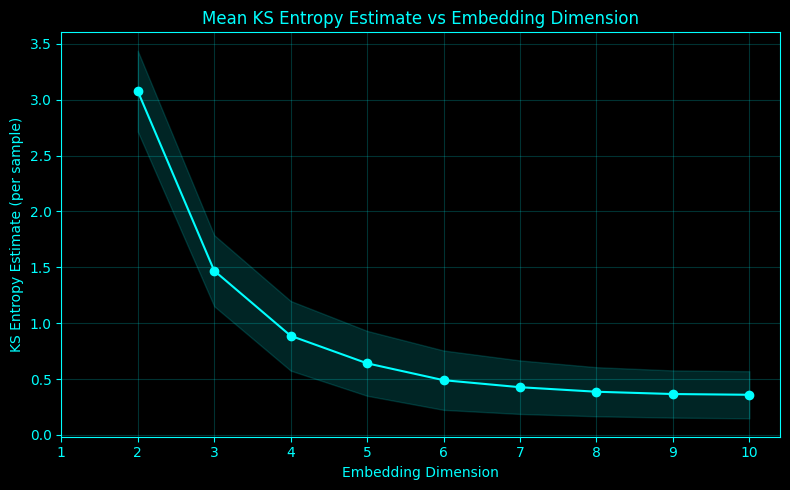

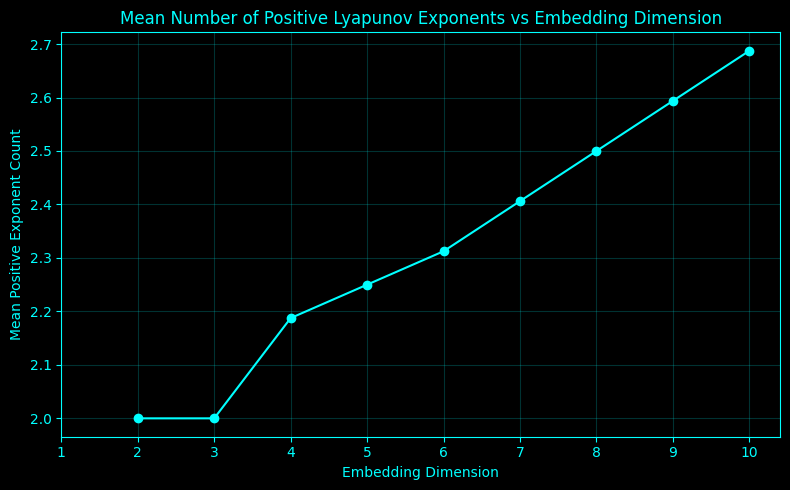

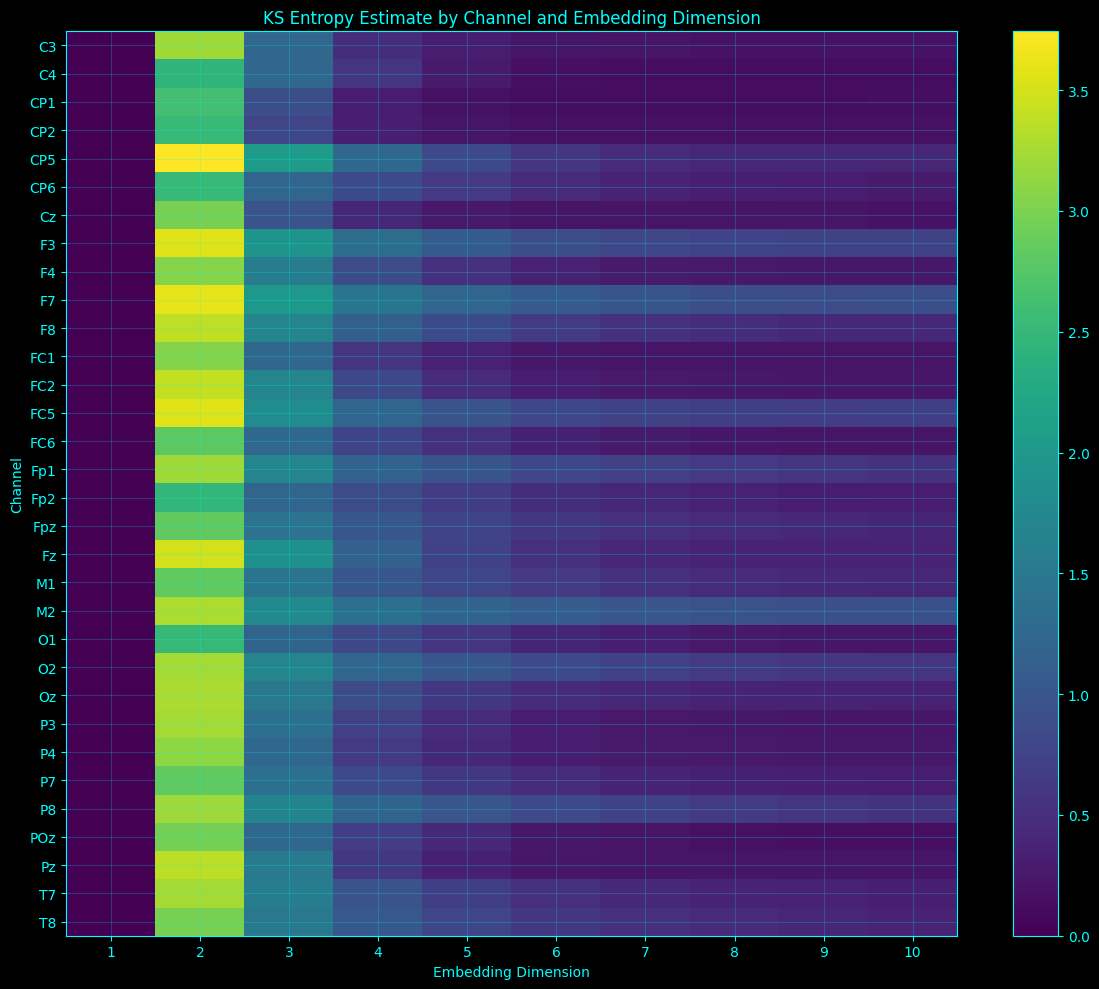

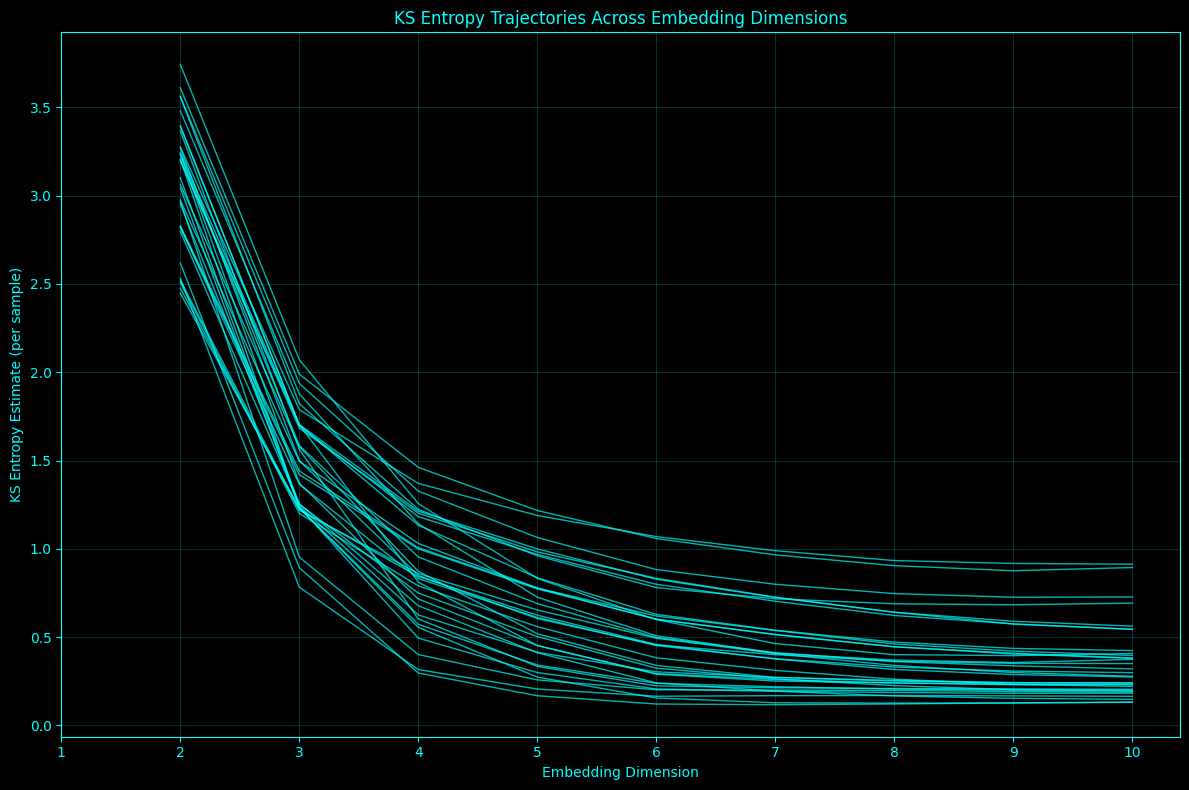


Saved per-file KS CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/ks_entropy_from_lyapunov/ks_entropy_per_file.csv
Saved dimension summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/ks_entropy_from_lyapunov/ks_entropy_by_dimension.csv
Saved KS matrix CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/ks_entropy_from_lyapunov/ks_entropy_channel_dimension_matrix.csv
Saved positive-count matrix CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/ks_entropy_from_lyapunov/positive_exponent_count_channel_dimension_matrix.csv
Saved highest-dimension summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/ks_entropy_from_lyapunov/ks_entropy_highest_available_dimension_per_channel.csv
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/ks_entropy_from_lyapunov/ks_entropy_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/ks_entropy_from_lyapunov/plots


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
lyap_dir = os.path.join(base_dir, "results", "lyapunov_custom")
out_dir = os.path.join(base_dir, "results", "ks_entropy_from_lyapunov")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"
eps = 1e-12

# IMPORTANT:
# If your Lyapunov code used DT = 1.0, then KS entropy here is "per sample".
# If your Lyapunov code used DT = 1/fs, then KS entropy here is "per second".
KS_UNITS = "per sample"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def find_latest_lyapunov_csv(results_dir):
    csvs = sorted(glob.glob(os.path.join(results_dir, "lyap_spectrum_*.csv")))
    if not csvs:
        raise FileNotFoundError(f"No lyap_spectrum_*.csv files found in: {results_dir}")
    return max(csvs, key=os.path.getmtime)

def get_exp_cols(df):
    exp_cols = [c for c in df.columns if str(c).startswith("Exp")]
    exp_cols = sorted(exp_cols, key=lambda c: int(str(c).replace("Exp", "")))
    return exp_cols

def infer_channel_from_stem(stem):
    stem = str(stem)
    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]
    return stem

def infer_embedding_dimension(row):
    if "embedding_dimension" in row.index and pd.notna(row["embedding_dimension"]):
        try:
            return int(row["embedding_dimension"])
        except Exception:
            pass

    stem = str(row["stem"])
    if "dembedded_" in stem:
        left = stem.split("dembedded_", 1)[0]
        try:
            return int(left)
        except Exception:
            pass

    if "state_dim" in row.index and pd.notna(row["state_dim"]):
        try:
            return int(row["state_dim"])
        except Exception:
            pass

    return np.nan

def row_exponents(row, exp_cols):
    vals = []
    for c in exp_cols:
        if c in row.index and pd.notna(row[c]):
            vals.append(float(row[c]))
    return np.asarray(vals, dtype=float)

def ks_entropy_estimate(lyapunov_exponents):
    """
    Pesin-type estimate:
        h_KS ≈ sum of positive Lyapunov exponents
    """
    exps = np.asarray(lyapunov_exponents, dtype=float)
    exps = exps[np.isfinite(exps)]
    if exps.size == 0:
        return np.nan
    return float(np.sum(exps[exps > 0]))

def positive_lyapunov_count(lyapunov_exponents):
    exps = np.asarray(lyapunov_exponents, dtype=float)
    exps = exps[np.isfinite(exps)]
    return int(np.sum(exps > 0))

def largest_lyapunov(lyapunov_exponents):
    exps = np.asarray(lyapunov_exponents, dtype=float)
    exps = exps[np.isfinite(exps)]
    if exps.size == 0:
        return np.nan
    return float(np.max(exps))

# -------------------------------------------------------
# LOAD LATEST LYAPUNOV CSV
# -------------------------------------------------------
lyap_csv = find_latest_lyapunov_csv(lyap_dir)
df = pd.read_csv(lyap_csv)

print("Using Lyapunov CSV:")
print(lyap_csv)

if "status" in df.columns:
    df = df[df["status"] == "ok"].copy()

if df.empty:
    raise ValueError("No successful rows found in the Lyapunov CSV.")

exp_cols = get_exp_cols(df)
if not exp_cols:
    raise ValueError("No Exp columns found in the Lyapunov CSV.")

print("\nDetected exponent columns:")
print(exp_cols)

# -------------------------------------------------------
# BUILD KS TABLE
# -------------------------------------------------------
records = []

for _, row in df.iterrows():
    stem = row["stem"] if "stem" in row.index else ""
    channel = infer_channel_from_stem(stem)
    emb_dim = infer_embedding_dimension(row)
    exps = row_exponents(row, exp_cols)

    if exps.size == 0:
        continue

    exps_sorted = np.sort(exps)[::-1]
    ks_est = ks_entropy_estimate(exps_sorted)
    n_pos = positive_lyapunov_count(exps_sorted)
    lmax = largest_lyapunov(exps_sorted)

    rec = {
        "file": row["file"] if "file" in row.index else "",
        "stem": stem,
        "channel": channel,
        "embedding_dimension": emb_dim,
        "state_dim": int(row["state_dim"]) if "state_dim" in row.index and pd.notna(row["state_dim"]) else np.nan,
        "n_samples": int(row["n_samples"]) if "n_samples" in row.index and pd.notna(row["n_samples"]) else np.nan,
        "steps_used": int(row["steps_used"]) if "steps_used" in row.index and pd.notna(row["steps_used"]) else np.nan,
        "n_exponents_used": int(exps_sorted.size),
        "largest_lyapunov_exponent": float(lmax),
        "n_positive_exponents": int(n_pos),
        "sum_positive_exponents": float(ks_est),
        "ks_entropy_estimate": float(ks_est),
        "sum_all_exponents": float(np.sum(exps_sorted)),
    }

    for i, val in enumerate(exps_sorted, start=1):
        rec[f"sorted_Exp{i}"] = float(val)

    records.append(rec)

ks_df = pd.DataFrame(records)

if ks_df.empty:
    raise ValueError("No KS entropy records were produced.")

ks_df = ks_df.sort_values(["channel", "embedding_dimension"]).reset_index(drop=True)

# -------------------------------------------------------
# SUMMARIES
# -------------------------------------------------------
all_dims = list(range(1, 11))

dim_summary_df = (
    ks_df.groupby("embedding_dimension", dropna=True)
    .agg(
        n_records=("ks_entropy_estimate", "count"),
        mean_ks_entropy=("ks_entropy_estimate", "mean"),
        std_ks_entropy=("ks_entropy_estimate", "std"),
        mean_lmax=("largest_lyapunov_exponent", "mean"),
        mean_positive_count=("n_positive_exponents", "mean"),
        mean_sum_all_exponents=("sum_all_exponents", "mean"),
    )
    .reset_index()
)

dim_summary_full = pd.DataFrame({"embedding_dimension": all_dims}).merge(
    dim_summary_df,
    on="embedding_dimension",
    how="left"
)

ks_matrix = ks_df.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="ks_entropy_estimate",
    aggfunc="mean"
).reindex(columns=all_dims)

poscount_matrix = ks_df.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="n_positive_exponents",
    aggfunc="mean"
).reindex(columns=all_dims)

# highest available dimension per channel
highest_dim_df = (
    ks_df.sort_values(["channel", "embedding_dimension"])
    .groupby("channel", as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

# -------------------------------------------------------
# SAVE TABLES
# -------------------------------------------------------
ks_csv = os.path.join(out_dir, "ks_entropy_per_file.csv")
dim_csv = os.path.join(out_dir, "ks_entropy_by_dimension.csv")
matrix_csv = os.path.join(out_dir, "ks_entropy_channel_dimension_matrix.csv")
poscount_csv = os.path.join(out_dir, "positive_exponent_count_channel_dimension_matrix.csv")
highest_csv = os.path.join(out_dir, "ks_entropy_highest_available_dimension_per_channel.csv")

ks_df.to_csv(ks_csv, index=False)
dim_summary_full.to_csv(dim_csv, index=False)
ks_matrix.to_csv(matrix_csv)
poscount_matrix.to_csv(poscount_csv)
highest_dim_df.to_csv(highest_csv, index=False)

summary_txt = os.path.join(out_dir, "ks_entropy_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Kolmogorov-Sinai Entropy Estimate from Saved Lyapunov Spectra\n")
    f.write("===========================================================\n\n")
    f.write(f"Source CSV: {lyap_csv}\n")
    f.write(f"Rows analyzed: {len(ks_df)}\n")
    f.write(f"Exponent columns used: {', '.join(exp_cols)}\n")
    f.write(f"KS entropy units: {KS_UNITS}\n\n")
    f.write("Estimate used:\n")
    f.write("  h_KS ≈ sum of positive Lyapunov exponents\n\n")

    f.write("Mean KS entropy by embedding dimension:\n")
    for _, row in dim_summary_full.iterrows():
        d = int(row["embedding_dimension"])
        nrec = row["n_records"]
        if pd.isna(nrec):
            f.write(f"  {d}D: no data\n")
        else:
            f.write(
                f"  {d}D: n={int(nrec)}, "
                f"mean_KS={row['mean_ks_entropy']:.6f}, "
                f"std_KS={0.0 if pd.isna(row['std_ks_entropy']) else row['std_ks_entropy']:.6f}, "
                f"mean_Lmax={row['mean_lmax']:.6f}, "
                f"mean_positive_count={row['mean_positive_count']:.3f}, "
                f"mean_sum_all_exp={row['mean_sum_all_exponents']:.6f}\n"
            )

# -------------------------------------------------------
# PRINT
# -------------------------------------------------------
print("\nKS entropy by embedding dimension:")
print(dim_summary_full)

print("\nSample per-file KS results:")
print(ks_df.head())

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# Plot 1: mean KS entropy vs embedding dimension
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

mask = dim_summary_full["mean_ks_entropy"].notna().values
x = dim_summary_full.loc[mask, "embedding_dimension"].values
y = dim_summary_full.loc[mask, "mean_ks_entropy"].values
s = dim_summary_full.loc[mask, "std_ks_entropy"].fillna(0.0).values

ax.plot(x, y, marker="o", color=ACCENT, linewidth=1.5)
ax.fill_between(x, y - s, y + s, color=ACCENT, alpha=0.15)
ax.set_title("Mean KS Entropy Estimate vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel(f"KS Entropy Estimate ({KS_UNITS})")
ax.set_xticks(all_dims)

plot1_path = os.path.join(plots_dir, "mean_ks_entropy_vs_embedding_dimension.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Plot 2: mean number of positive exponents vs embedding dimension
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

mask = dim_summary_full["mean_positive_count"].notna().values
ax.plot(
    dim_summary_full.loc[mask, "embedding_dimension"].values,
    dim_summary_full.loc[mask, "mean_positive_count"].values,
    marker="o",
    color=ACCENT,
    linewidth=1.5
)
ax.set_title("Mean Number of Positive Lyapunov Exponents vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Mean Positive Exponent Count")
ax.set_xticks(all_dims)

plot2_path = os.path.join(plots_dir, "mean_positive_exponent_count_vs_embedding_dimension.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Plot 3: channel x dimension heatmap of KS entropy
fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax)

heat_vals = ks_matrix.values.astype(float)
plot_vals = np.where(np.isnan(heat_vals), 0.0, heat_vals)

im = ax.imshow(plot_vals, aspect="auto")
ax.set_title("KS Entropy Estimate by Channel and Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(all_dims)))
ax.set_xticklabels(all_dims)
ax.set_yticks(np.arange(len(ks_matrix.index)))
ax.set_yticklabels(ks_matrix.index)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot3_path = os.path.join(plots_dir, "ks_entropy_heatmap_channel_by_dimension.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Plot 4: channel trajectories across dimensions
fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
style_ax(ax)

for ch in ks_matrix.index:
    y = ks_matrix.loc[ch].values.astype(float)
    x = np.array(all_dims, dtype=float)
    mask = np.isfinite(y)
    if np.sum(mask) >= 2:
        ax.plot(x[mask], y[mask], linewidth=1.0, alpha=0.7, color=ACCENT)

ax.set_title("KS Entropy Trajectories Across Embedding Dimensions")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel(f"KS Entropy Estimate ({KS_UNITS})")
ax.set_xticks(all_dims)

plot4_path = os.path.join(plots_dir, "ks_entropy_trajectories_across_dimensions.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved per-file KS CSV: {ks_csv}")
print(f"Saved dimension summary CSV: {dim_csv}")
print(f"Saved KS matrix CSV: {matrix_csv}")
print(f"Saved positive-count matrix CSV: {poscount_csv}")
print(f"Saved highest-dimension summary CSV: {highest_csv}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")